# Part II: PyTorch Sequence Model (M5)

The question this milestone answers is narrow: **does a deep sequence model
find anything the cheap models miss?** The candidate is a causal dilated
temporal convolutional network (TCN) over per-cell minute sequences, trained
with a vega-weighted Huber loss, evaluated on **row-identical** purged
walk-forward splits so every comparison is apples to apples.

The registered answer, from an 11-run sweep on the full 64-session panel
(single consumer GPU, ~15h wall): **no**. This notebook shows the model and
renders the sweep's registered results (recorded in FINDINGS.md and MLflow;
run provenance in the memo footnote).

In [1]:
import os, sys, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The research library and data live in the (private) qfdev_research repo,
# checked out as a sibling of this showcase repo. Override with QFDEV_RESEARCH.
RESEARCH = os.path.abspath(os.environ.get('QFDEV_RESEARCH', '../../qfdev_research'))
assert os.path.isdir(os.path.join(RESEARCH, 'quant')), RESEARCH
sys.path.insert(0, RESEARCH)

plt.rcParams['figure.figsize'] = (10, 4)
pd.set_option('display.width', 160)

import torch
from quant.forecasting import config as C
from quant.forecasting.tcn import TCN, receptive_field
from quant.forecasting.seq_data import SEQ_CHANNELS, STATIC_COLS

model = TCN(n_seq_channels=len(SEQ_CHANNELS), n_static=len(STATIC_COLS))
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n{len(SEQ_CHANNELS)} sequence channels: {SEQ_CHANNELS}")
print(f"{len(STATIC_COLS)} static covariates: {STATIC_COLS}")
print(f"kernel {C.TCN_KERNEL}, dilations {C.TCN_DILATIONS} -> "
      f"receptive field {receptive_field()} minutes | {n_params:,} parameters")

TCN(
  (blocks): Sequential(
    (0): _TemporalBlock(
      (conv1): _CausalConv(
        (conv): ParametrizedConv1d(
          13, 32, kernel_size=(2,), stride=(1,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      )
      (conv2): _CausalConv(
        (conv): ParametrizedConv1d(
          32, 32, kernel_size=(2,), stride=(1,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
          )
        )
      )
      (drop): Dropout1d(p=0.2, inplace=False)
      (res): Conv1d(13, 32, kernel_size=(1,), stride=(1,))
    )
    (1): _TemporalBlock(
      (conv1): _CausalConv(
        (conv): ParametrizedConv1d(
          32, 32, kernel_size=(2,), stride=(1,), dilation=(2,)
          (parametrizations): ModuleDict(
            (weight): ParametrizationList(
              (0): _WeightNorm()
            )
   

Design notes: convolutions are causal (the last step of the output is time
`t`), sequence channels carry the per-cell and surface-level dynamics, and
statics (cell identity, time of day) enter a small head after the temporal
embedding. Determinism is pinned (seeded, deterministic algorithms) so folds
are reproducible.

## Stage A: five-way comparison, all 64 sessions

MSE skill versus persistence, out of sample, identical rows per horizon
(about 2.0M rows at 5m). Values from the registered sweep:

,ridge,lgbm,tcn
horizon,,,
5,0.250,0.235,0.257
15,0.261,0.251,0.248
30,0.278,0.282,0.259
60,0.364,0.397,0.375


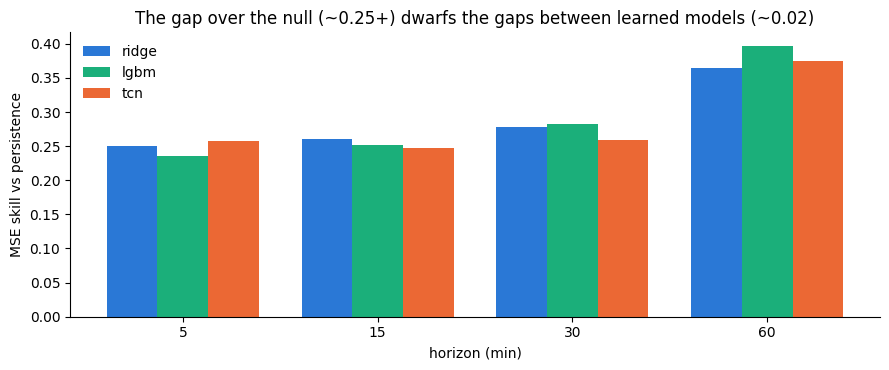

In [2]:
stage_a = pd.DataFrame({
    'horizon': [5, 15, 30, 60],
    'ridge':   [0.250, 0.261, 0.278, 0.364],
    'lgbm':    [0.235, 0.251, 0.282, 0.397],
    'tcn':     [0.257, 0.248, 0.259, 0.375],
}).set_index('horizon')
display(stage_a)

fig, ax = plt.subplots(figsize=(9, 3.8))
x = np.arange(4); wd = 0.26
for j, (m, c) in enumerate([('ridge', '#2a78d6'), ('lgbm', '#1baf7a'), ('tcn', '#eb6834')]):
    ax.bar(x + (j - 1) * wd, stage_a[m], wd, label=m, color=c)
ax.set_xticks(x, stage_a.index.astype(str)); ax.set_xlabel('horizon (min)')
ax.set_ylabel('MSE skill vs persistence')
ax.set_title('The gap over the null (~0.25+) dwarfs the gaps between learned models (~0.02)')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

The TCN ties the best cheap model at 5 minutes and loses at 30 and 60.
Pearson IC 0.49 to 0.62 and directional accuracy 56 to 60% confirm the
*signal* is strong everywhere; the *architecture* adds nothing on top of the
29-feature set.

## Stage B: receptive-field ablation

The sharpest summary of the negative result. TCN skill as the receptive
field grows from 3 to 63 minutes, with `min_history` pinned so every rung
sees the identical row set:

,5m,15m,30m,60m
rf_min,,,,
3,0.204,0.202,0.228,0.362
7,0.241,0.237,0.253,0.376
15,0.249,0.237,0.246,0.379
31,0.246,0.242,0.250,0.362
63,0.245,0.246,0.262,0.376


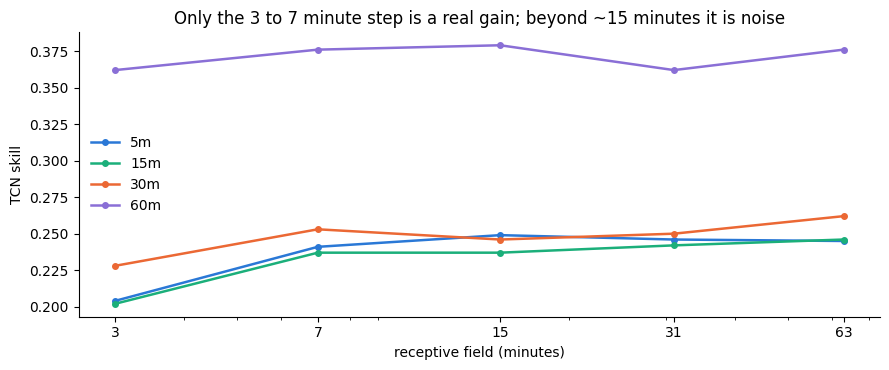

In [3]:
stage_b = pd.DataFrame({
    'rf_min': [3, 7, 15, 31, 63],
    '5m':  [0.204, 0.241, 0.249, 0.246, 0.245],
    '15m': [0.202, 0.237, 0.237, 0.242, 0.246],
    '30m': [0.228, 0.253, 0.246, 0.250, 0.262],
    '60m': [0.362, 0.376, 0.379, 0.362, 0.376],
}).set_index('rf_min')
display(stage_b)

fig, ax = plt.subplots(figsize=(9, 3.8))
for h, c in zip(['5m', '15m', '30m', '60m'], ['#2a78d6', '#1baf7a', '#eb6834', '#8a6fd6']):
    ax.plot(stage_b.index, stage_b[h], marker='o', ms=4, lw=1.8, label=h, color=c)
ax.set_xscale('log'); ax.set_xticks(stage_b.index); ax.set_xticklabels(stage_b.index)
ax.set_xlabel('receptive field (minutes)'); ax.set_ylabel('TCN skill')
ax.set_title('Only the 3 to 7 minute step is a real gain; beyond ~15 minutes it is noise')
ax.legend(frameon=False); ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()

All the temporal signal lives in the last ~7 to 15 minutes. Even at the
60-minute horizon the 3-minute-memory model is within noise of the deepest:
long-horizon predictability is carried by current state, not path. (Anchor
baselines on the same pinned rows: 5m ridge 0.246 / LightGBM 0.227; 60m
ridge 0.373 / LightGBM 0.401.)

## Stage C: capacity and regularization

In [4]:
stage_c = pd.DataFrame({
    'config': ['default (ch32, dropout 0.2)', 'channels 16', 'channels 64',
               'dropout 0.0', 'dropout 0.4'],
    '5m':  [0.257, 0.244, 0.258, 0.277, 0.242],
    '60m': [0.375, 0.358, 0.382, 0.389, 0.346],
}).set_index('config')
display(stage_c)
print('The one signal in the capacity sweep: dropout 0.0 is best on both horizons,')
print('so the model was not overfitting; the default 0.2 just discarded capacity.')

,5m,60m
config,,
"default (ch32, dropout 0.2)",0.257,0.375
channels 16,0.244,0.358
channels 64,0.258,0.382
dropout 0.0,0.277,0.389
dropout 0.4,0.242,0.346


The one signal in the capacity sweep: dropout 0.0 is best on both horizons,
so the model was not overfitting; the default 0.2 just discarded capacity.


## Verdict

A defensible negative result on architecture: a cheap model with 7 to 15
minutes of context extracts essentially everything the deep sequence model
finds in this representation. The shuffled-label control on the same panel
(notebook 03; excess +0.0010 against a 0.02 tolerance) certifies the harness
is leak-free, so the tie is real rather than an artifact. The next lever is
cross-sectional feature structure, not a bigger network; the economic
consequences of the forecasts as they stand are notebook 06.